In [1]:
import torch
import torch.nn as nn
from torchvision.transforms import transforms
from torch.utils.data import DataLoader
from matplotlib import pyplot as plt
import pandas as pd
import torch.optim as optim
from tqdm import tqdm
from torchinfo import summary
import numpy as np

from model import EmotionClassifier
from get_dataset import GiMeFiveDataset
from variables import experiments, datasets

from os import mkdir, path

device = torch.device("mps" if torch.backends.mps.is_available() else "cpu")

# Change the experiment only
experiment_name = "class_weights_ADAM"

configuration = experiments[experiment_name]
dataset = datasets[configuration["dataset"]]
hyperparameters = configuration["hyperparameters"]

print(f"Using device: {device}")

Using device: mps


In [2]:
transform = transforms.Compose(
    [
        transforms.Resize((64, 64)),
        transforms.Grayscale(num_output_channels=3),
        transforms.RandomHorizontalFlip(),
        transforms.ToTensor(),
        transforms.Normalize(mean=[0.485, 0.456, 0.406], std=[0.229, 0.224, 0.225]),
    ]
)

train_dataset = GiMeFiveDataset(
    csv_file=dataset["train"]["labels"],
    img_dir=dataset["train"]["images"],
    transform=transform,
)
train_data_loader = DataLoader(
    train_dataset, batch_size=hyperparameters["batch_size"], shuffle=True, num_workers=4
)
train_image, train_label = next(iter(train_data_loader))
print(f"Train batch: image shape {train_image.shape}, labels shape {train_label.shape}")

validation_dataset = GiMeFiveDataset(
    csv_file=dataset["validation"]["labels"],
    img_dir=dataset["validation"]["images"],
    transform=transform,
)
validation_data_loader = DataLoader(
    validation_dataset,
    batch_size=hyperparameters["batch_size"],
    shuffle=False,
    num_workers=0,
)
validation_image, validation_label = next(iter(validation_data_loader))
print(
    f"Validation batch: image shape {validation_image.shape}, labels shape {validation_label.shape}"
)

test_dataset = GiMeFiveDataset(
    csv_file=dataset["test"]["labels"],
    img_dir=dataset["test"]["images"],
    transform=transform,
)

test_data_loader = DataLoader(
    test_dataset, batch_size=hyperparameters["batch_size"], shuffle=False, num_workers=0
)

test_image, test_label = next(iter(test_data_loader))
print(f"Test batch: image shape {test_image.shape}, labels shape {test_label.shape}")

Train batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Validation batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])
Test batch: image shape torch.Size([16, 3, 64, 64]), labels shape torch.Size([16])


In [3]:
model = EmotionClassifier().to(device)

print(
    summary(model, input_size=(hyperparameters["batch_size"], 3, 64, 64), device="mps")
)

# total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
# print(f"Total trainable parameters: {total_params}")

Layer (type:depth-idx)                   Output Shape              Param #
EmotionClassifier                        [16, 6]                   --
├─Conv2d: 1-1                            [16, 64, 64, 64]          1,792
├─BatchNorm2d: 1-2                       [16, 64, 64, 64]          128
├─Dropout: 1-3                           [16, 64, 32, 32]          --
├─Conv2d: 1-4                            [16, 128, 32, 32]         73,856
├─BatchNorm2d: 1-5                       [16, 128, 32, 32]         256
├─Dropout: 1-6                           [16, 128, 16, 16]         --
├─Conv2d: 1-7                            [16, 256, 16, 16]         295,168
├─BatchNorm2d: 1-8                       [16, 256, 16, 16]         512
├─Dropout: 1-9                           [16, 256, 8, 8]           --
├─Conv2d: 1-10                           [16, 512, 8, 8]           1,180,160
├─BatchNorm2d: 1-11                      [16, 512, 8, 8]           1,024
├─Dropout: 1-12                          [16, 512, 4, 4]    

In [4]:
# Input weight balancing.

if configuration["apply_class_weight"]:
    def get_class_weights(dataset):
        total_samples = len(dataset)
        unique_labels = np.unique([label for _, label in dataset], return_counts=True)[
            1
        ]

        class_weights = [(total_samples / count) for count in unique_labels]
        return class_weights

    class_weights = torch.Tensor(get_class_weights(train_dataset)).to(device)
    print("Using CrossEntropyLoss with class weights:", class_weights)
    criterion = nn.CrossEntropyLoss(weight=class_weights)
else:
    print("Using CrossEntropyLoss without class weights")
    criterion = nn.CrossEntropyLoss()

Using CrossEntropyLoss with class weights: tensor([ 3.2134,  6.3895,  5.5237,  6.8873, 14.7683,  7.2281], device='mps:0')


In [5]:
print("Using", configuration["optimizer"])

match configuration["optimizer"]:
    case "adam_optimizer":
        optimizer = optim.Adam(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            weight_decay=hyperparameters["weight_decay"],
        )
    case "sgd_optimizer":
        optimizer = optim.SGD(
            model.parameters(),
            lr=hyperparameters["learning_rate"],
            momentum=hyperparameters["momentum"],
            weight_decay=hyperparameters["weight_decay"],
        )

best_val_acc = 0

num_epochs = hyperparameters["num_epochs"]

model_filename = f"outputs/{experiment_name}/model.pth"
if not path.exists(f"outputs/{experiment_name}"):
    mkdir(f"outputs/{experiment_name}")

Using sgd_optimizer


In [6]:
train_losses = []
val_losses = []
train_accuracies = []
val_accuracies = []
test_losses = []
test_accuracies = []

for epoch in range(num_epochs):
    model.train()
    running_loss = 0.0
    correct = 0
    total = 0

    for data in tqdm(train_data_loader, desc=f"Epoch {epoch+1}/{num_epochs}"):
        inputs, labels = data[0].to(device), data[1].to(device)

        optimizer.zero_grad()
        outputs = model(inputs)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        running_loss += loss.item()
        _, predicted = torch.max(outputs.data, 1)
        total += labels.size(0)
        correct += (predicted == labels).sum().item()

    train_loss = running_loss / len(train_data_loader)
    train_acc = correct / total
    train_losses.append(train_loss)
    train_accuracies.append(train_acc)

    model.eval()
    test_running_loss = 0.0
    test_correct = 0
    test_total = 0
    with torch.no_grad():
        for data in test_data_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            test_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            test_total += labels.size(0)
            test_correct += (predicted == labels).sum().item()

    test_loss = test_running_loss / len(test_data_loader)
    test_acc = test_correct / test_total
    test_losses.append(test_loss)
    test_accuracies.append(test_acc)

    model.eval()
    val_running_loss = 0.0
    val_correct = 0
    val_total = 0
    with torch.no_grad():
        for data in validation_data_loader:
            inputs, labels = data[0].to(device), data[1].to(device)
            outputs = model(inputs)
            loss = criterion(outputs, labels)
            val_running_loss += loss.item()
            _, predicted = torch.max(outputs.data, 1)
            val_total += labels.size(0)
            val_correct += (predicted == labels).sum().item()

    val_loss = val_running_loss / len(validation_data_loader)
    val_acc = val_correct / val_total
    val_losses.append(val_loss)
    val_accuracies.append(val_acc)

    print(
        f"Epoch {epoch+1}, Train Loss: {train_loss}, Train Accuracy: {train_acc}, Test Loss: {test_loss}, Test Accuracy: {test_acc}, Validation Loss: {val_loss}, Validation Accuracy: {val_acc}"
    )

    if val_acc > best_val_acc:
        best_val_acc = val_acc
        torch.save(model.state_dict(), model_filename)

Epoch 1/80: 100%|██████████| 3442/3442 [01:26<00:00, 39.74it/s]


Epoch 1, Train Loss: 1.6891612980270163, Train Accuracy: 0.3242904614043689, Test Loss: 1.370695990529948, Test Accuracy: 0.4721555448871819, Validation Loss: 1.9400303395170915, Validation Accuracy: 0.25542570951585974


Epoch 2/80: 100%|██████████| 3442/3442 [01:26<00:00, 39.91it/s]


Epoch 2, Train Loss: 1.4110539445760706, Train Accuracy: 0.47358864011911894, Test Loss: 1.1768962071060907, Test Accuracy: 0.5448871819491119, Validation Loss: 1.6647895605940568, Validation Accuracy: 0.41736227045075125


Epoch 3/80: 100%|██████████| 3442/3442 [01:26<00:00, 39.67it/s]


...

Epoch 78, Train Loss: 0.29928401824847767, Train Accuracy: 0.8948085199106608, Test Loss: 0.9102215989524787, Test Accuracy: 0.7396783485357658, Validation Loss: 1.312598547849216, Validation Accuracy: 0.7529215358931552


Epoch 79/80: 100%|██████████| 3442/3442 [01:24<00:00, 40.80it/s]


Epoch 79, Train Loss: 0.28821680242929526, Train Accuracy: 0.8998202320640628, Test Loss: 0.8902845583366089, Test Accuracy: 0.7447191550648103, Validation Loss: 1.2685788583598638, Validation Accuracy: 0.7662771285475793


Epoch 80/80: 100%|██████████| 3442/3442 [01:24<00:00, 40.83it/s]


Epoch 80, Train Loss: 0.28406726207501887, Train Accuracy: 0.8998383904414301, Test Loss: 0.9055447874159168, Test Accuracy: 0.7399183869419107, Validation Loss: 1.2729452313169052, Validation Accuracy: 0.7562604340567612


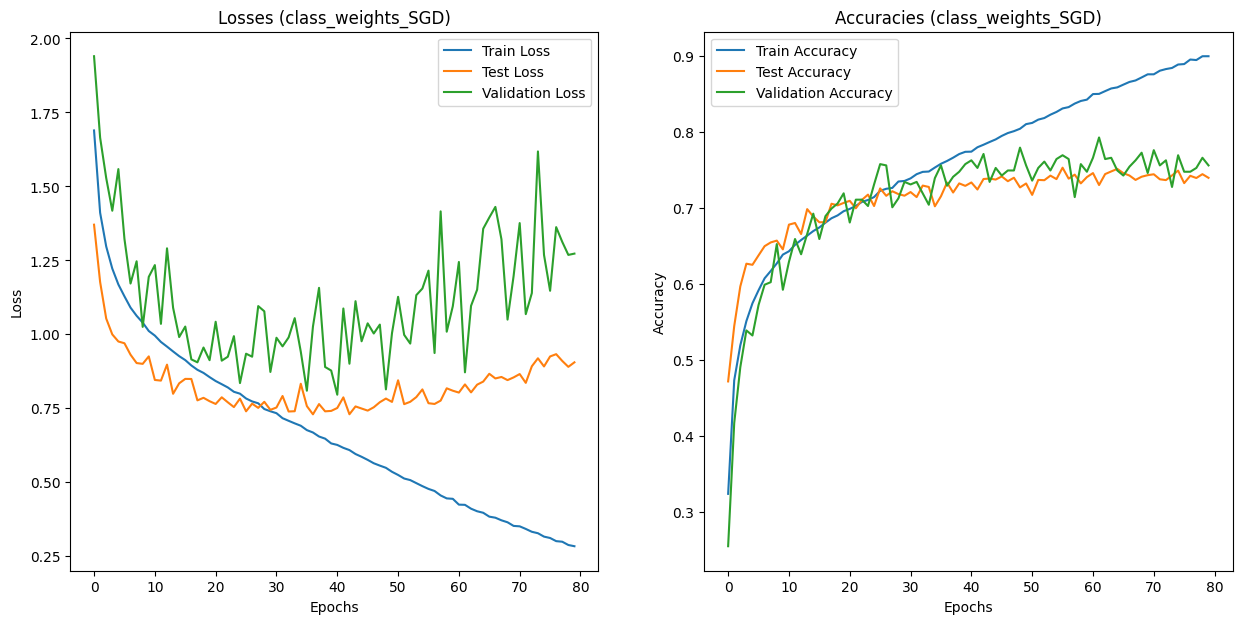

In [ ]:
file_name = f"outputs/{experiment_name}/learning_curve.png"

plt.figure(figsize=(15, 7))
plt.subplot(1, 2, 1)
plt.plot(range(num_epochs), train_losses, label="Train Loss")
plt.plot(range(num_epochs), test_losses, label="Test Loss")
plt.plot(range(num_epochs), val_losses, label="Validation Loss")
plt.xlabel("Epochs")
plt.ylabel("Loss")
plt.title(f"Losses ({experiment_name})")
plt.legend()

plt.subplot(1, 2, 2)
plt.plot(range(num_epochs), train_accuracies, label="Train Accuracy")
plt.plot(range(num_epochs), test_accuracies, label="Test Accuracy")
plt.plot(range(num_epochs), val_accuracies, label="Validation Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.title(f"Accuracies ({experiment_name})")
plt.legend()

plt.savefig(file_name, dpi=400, bbox_inches="tight", pad_inches=0.1)
plt.show()

In [11]:
df = pd.DataFrame(
    {
        "Epoch": range(
            1, num_epochs + 1
        ),  # change this number after '(1, _)' to num_epochs+1
        "Train Loss": train_losses,
        "Test Loss": test_losses,
        "Validation Loss": val_losses,
        "Train Accuracy": train_accuracies,
        "Test Accuracy": test_accuracies,
        "Validation Accuracy": val_accuracies,
    }
)
df.to_csv(
    f"outputs/{experiment_name}/result.csv",
    index=False,
)